In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab_Notebooks/Artificial_Perception

/content/drive/MyDrive/Colab_Notebooks/Artificial_Perception


# Lab 2 - Image Preprocessing

In this lab, we will explore the image preprocessing techniques that were covered in the lecture.

The goal of this lab is to see how images are preprocessed before feature extraction is performed (next week).

First, we will ensure that the correct libraries are installed.

In [ ]:
!pip install opencv-python matplotlib numpy

Now that the dependencies are installed, let's import the libraries that we are going to use today.

In [ ]:
print("Importing libraries...")
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Importing libraries...
Libraries imported successfully!


# What are we going to do today?

We are going to be using an image of Banksy's famous "Balloon Girl" artwork. It was painted on walls around London. The artwork depicts a young girl who is reaching towards a heart-shaped balloon.

Our goal today is to try and extract Banksy's artwork from the wall. We will attempt that by using **all** of the methods that we covered in this week's lecture.

Then, your task is to repeat the challenge on a new image.

# Step 1 - Loading the image

We are going to load an image of Banksy's "Balloon Girl". The image is available within this week's learning room on NTU Now. Ensure that the image is stored in the same location as this Python Notebook.

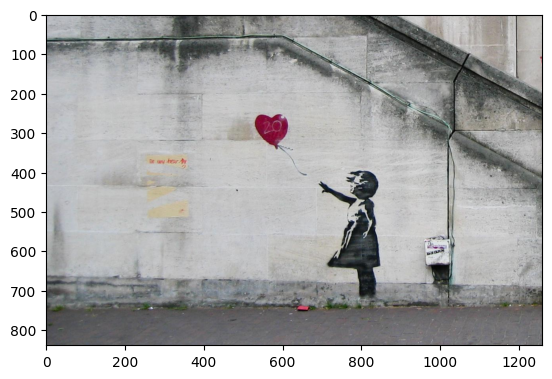

In [ ]:
img = cv2.imread("Banksy.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()

# Step 2 - Resizing the Image
Our image is quite large, so let's resize it to something a slightly smaller. Since our original image is 1259 x 839 pixels, we will resize it to approximately half that, 600 x 400.

Original image size:  (839, 1259, 3)
New image size:  (400, 600, 3)


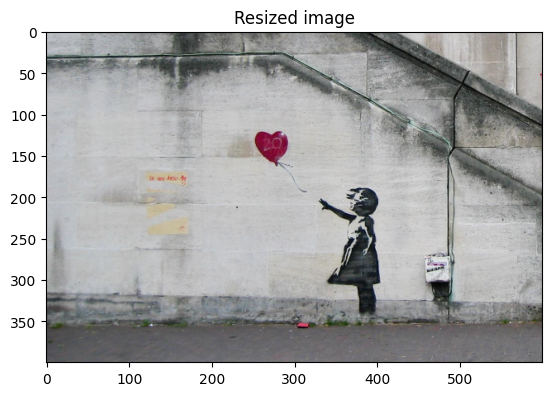

In [ ]:
print("Original image size: ", img.shape)
resized = cv2.resize(img, (600, 400))
print("New image size: ", resized.shape)

plt.imshow(resized)
plt.title("Resized image")
plt.show()


# Step 3 - Cropping the Image

Remember back to last week - an image is just an array of pixels. So, for cropping, we can just select rows and columns from the image.

Our new image is called "resized" and we can select pixels using square brackets.

In this example, we will select rows 100 down 350, and columns 200 across to 450.

Cropped image size (250, 250, 3)


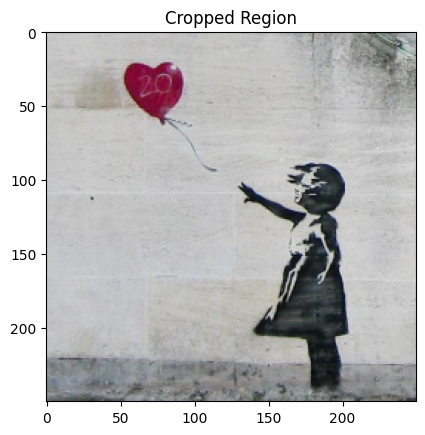

In [ ]:
crop = resized[100:350, 200:450]
print("Cropped image size", crop.shape)

plt.imshow(crop)
plt.title("Cropped Region")
plt.show()

# Noise Removal Example

Our example image is relatively clean, so to experiment with noise removal we will add some artificial noise to the image and then test out the two algorithms from the lecture (Gaussian and Median).

Run the first block of code to add noise to the image, and then the second block to remove the noise.

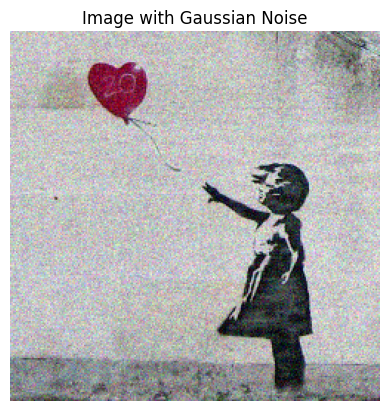

In [ ]:
crop_float = crop.astype(np.float32) # We will convert the image to floating point, just so we can generate some finer noise
noise = np.random.normal(0, 20, crop.shape).astype(np.float32) # We then generate some random noise
noisy_img = crop_float + noise # Add the pixels from the image to the random noise
noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8) # Clip the values back to 0-255

plt.imshow(noisy_img)
plt.axis("off")
plt.title("Image with Gaussian Noise")
plt.show()

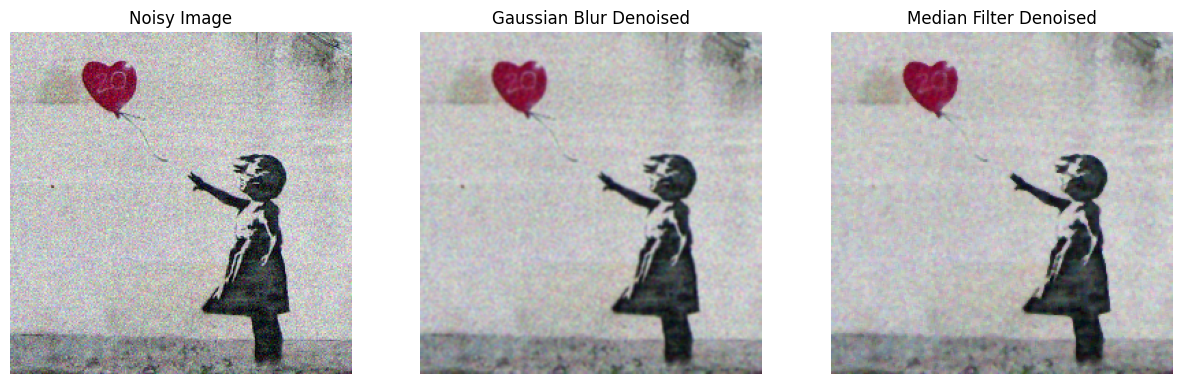

In [ ]:
gaussian_denoised = cv2.GaussianBlur(noisy_img, (3, 3), 0)
median_denoised = cv2.medianBlur(noisy_img, 3)

fig, axs = plt.subplots(1, 3, figsize=(15, 10))

axs[0].imshow(noisy_img)
axs[0].axis("off")
axs[0].set_title("Noisy Image")


axs[1].imshow(gaussian_denoised)
axs[1].axis("off")
axs[1].set_title("Gaussian Blur Denoised")


axs[2].imshow(median_denoised)
axs[2].axis("off")
axs[2].set_title("Median Filter Denoised")
plt.show()

**Point of Reflection**

In the following lines of code above:
*   gaussian_denoised = cv2.GaussianBlur(noisy_img, (3, 3), 0)
*   median_denoised = cv2.medianBlur(noisy_img, 3)

Try changing the number 3 to a higher value. What happens?

Find the two functions (GaussianBlur and medianBlur) in the OpenCV documentation to see why this is happening.

https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#gae8bdcd9154ed5ca3cbc1766d960f45c1

https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html#ga564869aa33e58769b4469101aac458f9




# Step 4 - Thresholding

We will now attempt the three types of thresholding that we covered in the lecture.

We will now convert the cropped image to greyscale before moving on...

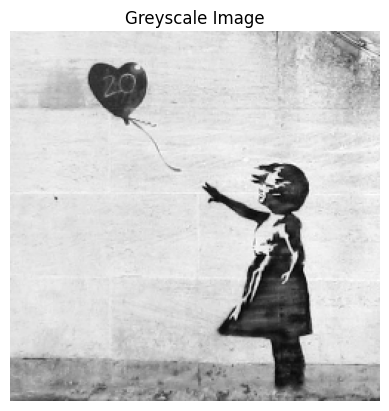

In [ ]:
grey = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

plt.imshow(grey, cmap="gray")
plt.axis("off")
plt.title("Greyscale Image")
plt.show()

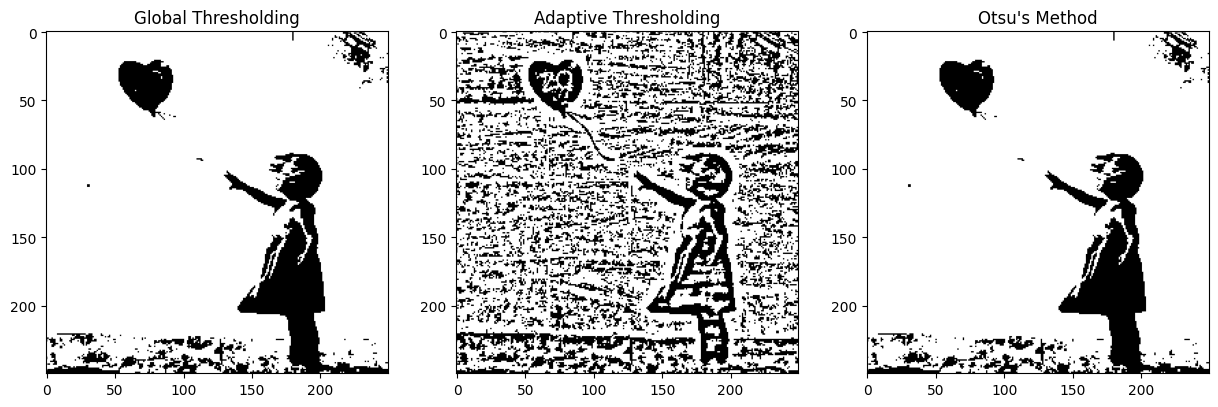

In [ ]:
# Global
_, global_thresh = cv2.threshold(grey, 127, 255, cv2.THRESH_BINARY)

# Adaptive
adaptive_thresh = cv2.adaptiveThreshold(grey, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)

# Otsu
_, otsu_thresh = cv2.threshold(grey, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(global_thresh, cmap="gray"); axs[0].set_title("Global Thresholding")
axs[1].imshow(adaptive_thresh, cmap="gray"); axs[1].set_title("Adaptive Thresholding")
axs[2].imshow(otsu_thresh, cmap="gray"); axs[2].set_title("Otsu's Method")
plt.show()

**Point of Reflection**

In the above images, we can make three observations:
1.   Adaptive thresholding produces a lot of unwanted artefacts. We are trying to extract the girl with the balloon, but using adaptive thresholding has detected a lot of the textures on the bricks.
2.   In this case, global threholding and Otsu's method produced similar results.
3.   The number on the balloon is readable in adaptive thresholding, but has been lost by the other two approaches.

Think back to the lecture slides and consider why the above may be happening.

# Changing Threshold Values

As we heard in the lecture, threshold methods that are **not** automated require a parameter T.

Our global threshold above used a value of 127 for T.

Since the number on the balloon was lost, this value was probably too high. So, let's try some more values...


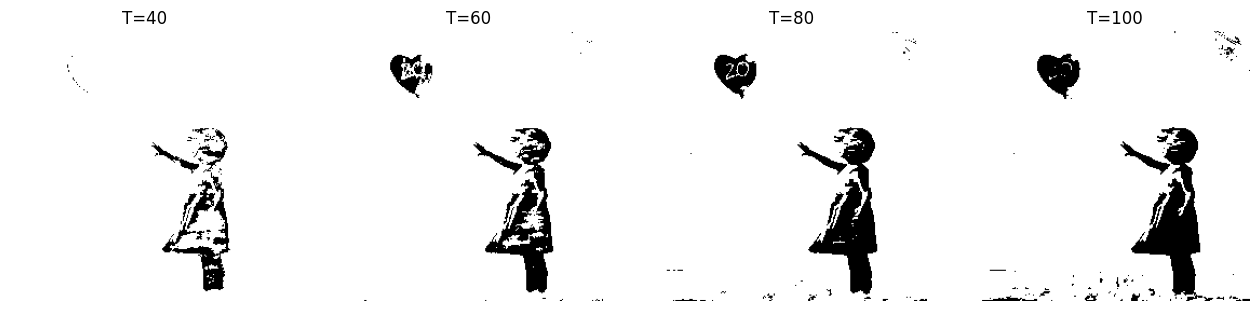

In [ ]:
_, global_thresh1 = cv2.threshold(grey, 40, 255, cv2.THRESH_BINARY)
_, global_thresh2 = cv2.threshold(grey, 60, 255, cv2.THRESH_BINARY)
_, global_thresh3 = cv2.threshold(grey, 80, 255, cv2.THRESH_BINARY)
_, global_thresh4 = cv2.threshold(grey, 100, 255, cv2.THRESH_BINARY)


fig, axs = plt.subplots(1, 4, figsize=(16, 6))
axs[0].imshow(global_thresh1, cmap="gray")
axs[0].set_title("T=40")
axs[0].axis("off")

axs[1].imshow(global_thresh2, cmap="gray")
axs[1].set_title("T=60")
axs[1].axis("off")

axs[2].imshow(global_thresh3, cmap="gray")
axs[2].set_title("T=80")
axs[2].axis("off")

axs[3].imshow(global_thresh4, cmap="gray")
axs[3].set_title("T=100")
axs[3].axis("off")

plt.show()

# Try it yourself

In the images above, we can see that T=80 seems to be particularly good at extracting the correct amount of detail on the image!

In the below code, the parameter "my_value" is set to 80. Try changing the number and see what happens. Can you find a better value than 80?

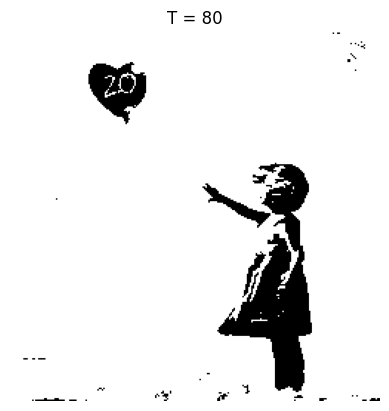

In [ ]:
my_value = 80 # Change this value!

# I think 75 is a more appropriate figure of 'my_value'

_, global_thresh = cv2.threshold(grey, my_value, 255, cv2.THRESH_BINARY)
plt.imshow(global_thresh, cmap="gray")
plt.axis("off")
plt.title("T = " + str(my_value))
plt.show()

# Step 5 - Edge Detection

Now let's try the final concept from the lecture, edge detection. In the below code, we will apply Sobel and Canny.

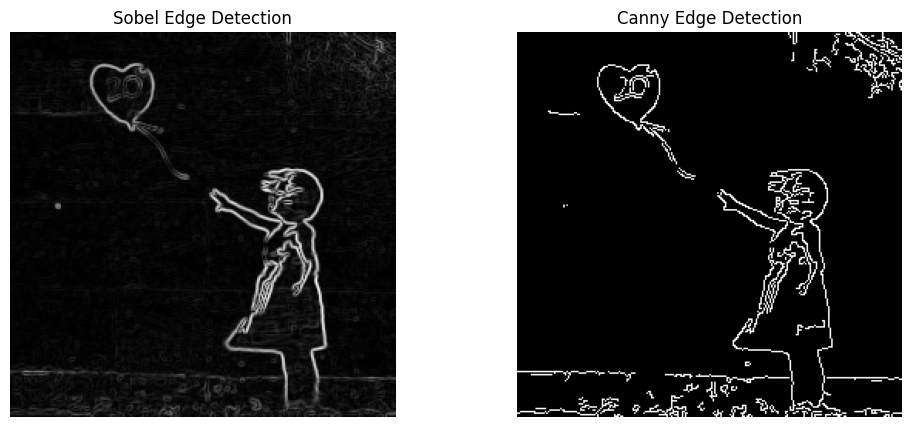

In [ ]:
sobelx = cv2.Sobel(grey, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(grey, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

canny_edges = cv2.Canny(grey, 100, 200)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(sobel_combined, cmap="gray"); axs[0].set_title("Sobel Edge Detection"); axs[0].axis("off")
axs[1].imshow(canny_edges, cmap="gray"); axs[1].set_title("Canny Edge Detection"); axs[1].axis("off")
plt.show()

# Lab Challenge

Now it's your turn!

The image found within this week's learning room ("NTU.png") is a photograph of a postgraduate welcome event taking place on the City campus.

In the below code, I have prepared a crop around the welcome sign.

**Your tasks**
1.   Convert the cropped sign to greyscale
2.   Experiment with preprocessing steps such as Gaussian blur and
3.   Apply global thresholding to the sign. Try different values for T to see which work best.
4.   Apply Otsu's method for thresholding and compare it with your manually tuned global value.
5.   Apply Sobel and Canny edge detection, which one works best for extracting the text?
6. **Stretch task** - try to apply preprocessing steps before thresholding and edge detection, can you create your own pipeline that performs well?

Note - all of the code you require can be found above in the provided examples. Your task is to find and apply the correct snippets.



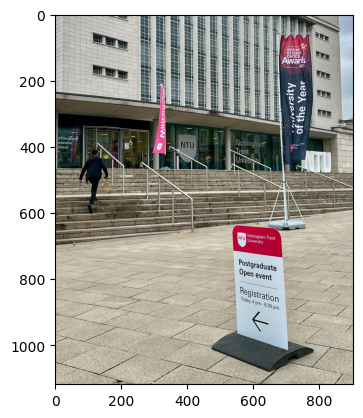

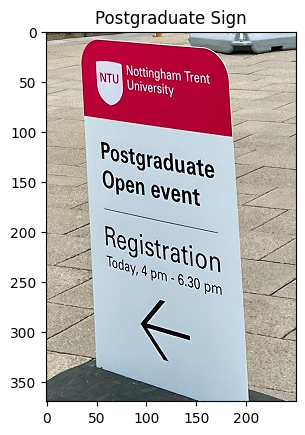

Cropped image size (370, 250, 3)


In [ ]:
img_ntu = cv2.imread("NTU.png")
img_ntu = cv2.cvtColor(img_ntu, cv2.COLOR_BGR2RGB)
plt.imshow(img_ntu)
plt.show()

postgraduate_sign = img_ntu[630:1000, 500:750]
plt.imshow(postgraduate_sign)
plt.title("Postgraduate Sign")
plt.show()
print("Cropped image size", postgraduate_sign.shape)

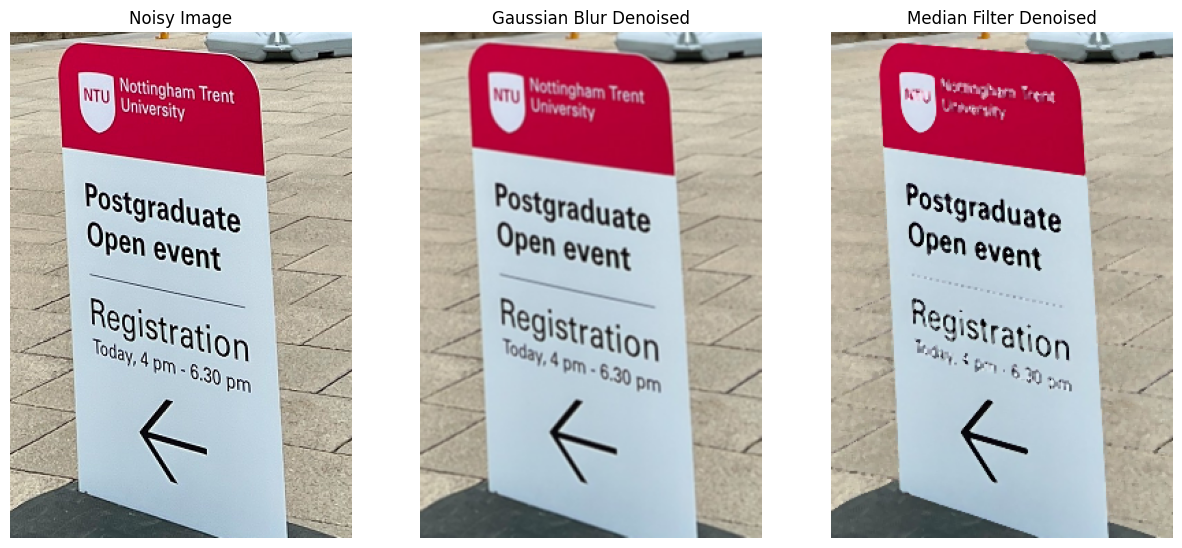

In [ ]:
# Denoised Image
denoised_gaussian = cv2.GaussianBlur(postgraduate_sign, (3, 3), 0)
median_denoised2 = cv2.medianBlur(postgraduate_sign, 3)

fig, axs = plt.subplots(1, 3, figsize=(15, 10))

axs[0].imshow(postgraduate_sign)
axs[0].axis("off")
axs[0].set_title("Noisy Image")


axs[1].imshow(denoised_gaussian)
axs[1].axis("off")
axs[1].set_title("Gaussian Blur Denoised")


axs[2].imshow(median_denoised2)
axs[2].axis("off")
axs[2].set_title("Median Filter Denoised")
plt.show()

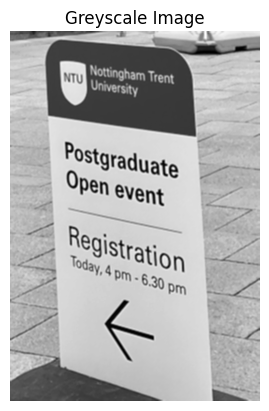

In [ ]:
# 1-2 Convert the cropped sign to greyscale
grey_sign = cv2.cvtColor(denoised_gaussian, cv2.COLOR_RGB2GRAY)

plt.imshow(grey_sign, cmap="gray")
plt.axis("off")
plt.title("Greyscale Image")
plt.show()

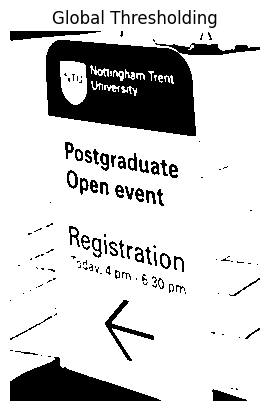

In [ ]:
# 3. Apply global thresholding to the sign. Try different values for T to see which work best.
_, g_thresh = cv2.threshold(grey_sign, 127, 255, cv2.THRESH_BINARY)

plt.imshow(g_thresh, cmap="gray")
plt.axis("off")
plt.title("Global Thresholding")
plt.show()

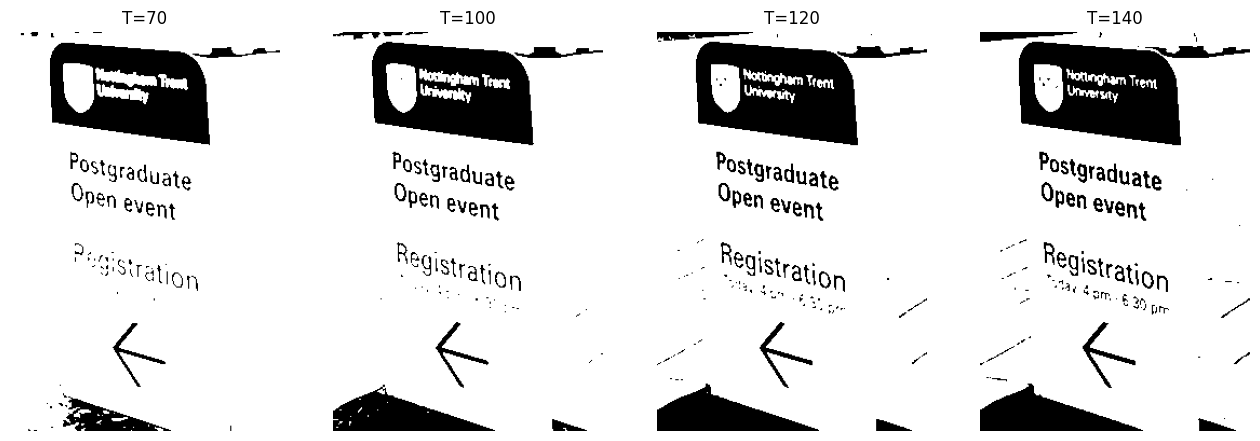

In [ ]:
_, g_thresh1 = cv2.threshold(grey_sign, 70, 255, cv2.THRESH_BINARY)
_, g_thresh2 = cv2.threshold(grey_sign, 90, 255, cv2.THRESH_BINARY)
_, g_thresh3 = cv2.threshold(grey_sign, 110, 255, cv2.THRESH_BINARY)
_, g_thresh4 = cv2.threshold(grey_sign, 120, 255, cv2.THRESH_BINARY)


fig, axs = plt.subplots(1, 4, figsize=(16, 6))
axs[0].imshow(g_thresh1, cmap="gray")
axs[0].set_title("T=70")
axs[0].axis("off")

axs[1].imshow(g_thresh2, cmap="gray")
axs[1].set_title("T=100")
axs[1].axis("off")

axs[2].imshow(g_thresh3, cmap="gray")
axs[2].set_title("T=120")
axs[2].axis("off")

axs[3].imshow(g_thresh4, cmap="gray")
axs[3].set_title("T=140")
axs[3].axis("off")

plt.show()

(370, 250) uint8


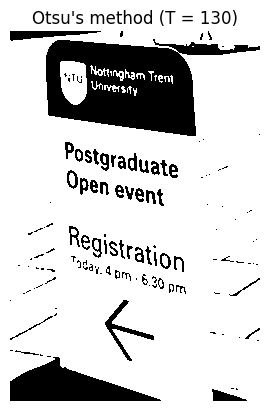

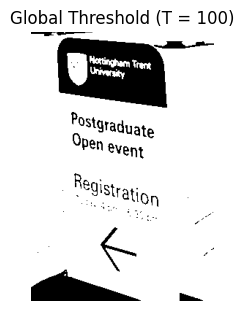

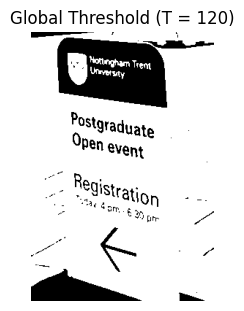

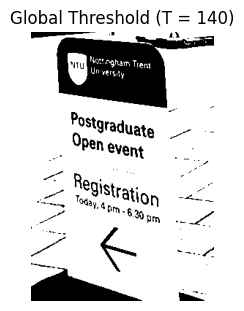

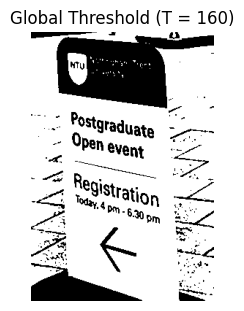

In [ ]:
# 4. Apply Otsu's method for thresholding and compare it with your manually tuned global value.
# First attempt
'''otsu_thresh_2 = cv2.threshold(grey_sign, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsu_thresh_2, cmap = "gray")
plt.axis("off")
plt.title("Otsu's method")
plt.show()'''


# Make sure grey_sign is a single-channel uint8 image
print(grey_sign.shape, grey_sign.dtype)  # should be (H, W) and uint8

# Otsu: unpack return values
otsu_T, otsu_img = cv2.threshold(grey_sign, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Show only the binary image
plt.imshow(otsu_img, cmap="gray")
plt.axis("off")
plt.title(f"Otsu's method (T = {otsu_T:.0f})")
plt.show()


for T in [100, 120, 140, 160]:
    _, global_img = cv2.threshold(grey_sign, T, 255, cv2.THRESH_BINARY)
    plt.figure(figsize=(3.5,3.5))
    plt.imshow(global_img, cmap="gray")
    plt.axis("off")
    plt.title(f"Global Threshold (T = {T})")
    plt.show()


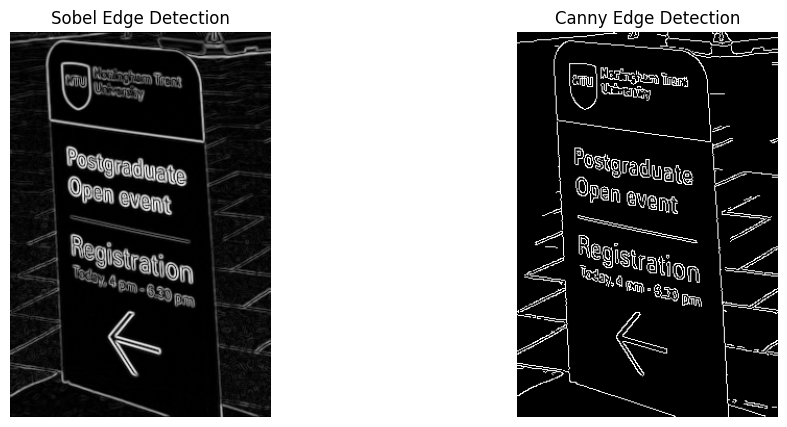

In [ ]:
# 5. Apply Sobel and Canny edge detection, which one works best for extracting the text?
sobelx = cv2.Sobel(grey_sign, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(grey_sign, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

canny_edges = cv2.Canny(grey_sign, 100, 200)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(sobel_combined, cmap="gray"); axs[0].set_title("Sobel Edge Detection"); axs[0].axis("off")
axs[1].imshow(canny_edges, cmap="gray"); axs[1].set_title("Canny Edge Detection"); axs[1].axis("off")
plt.show()

# For text-extraction specifically, *Canny Edge detection is preferable*

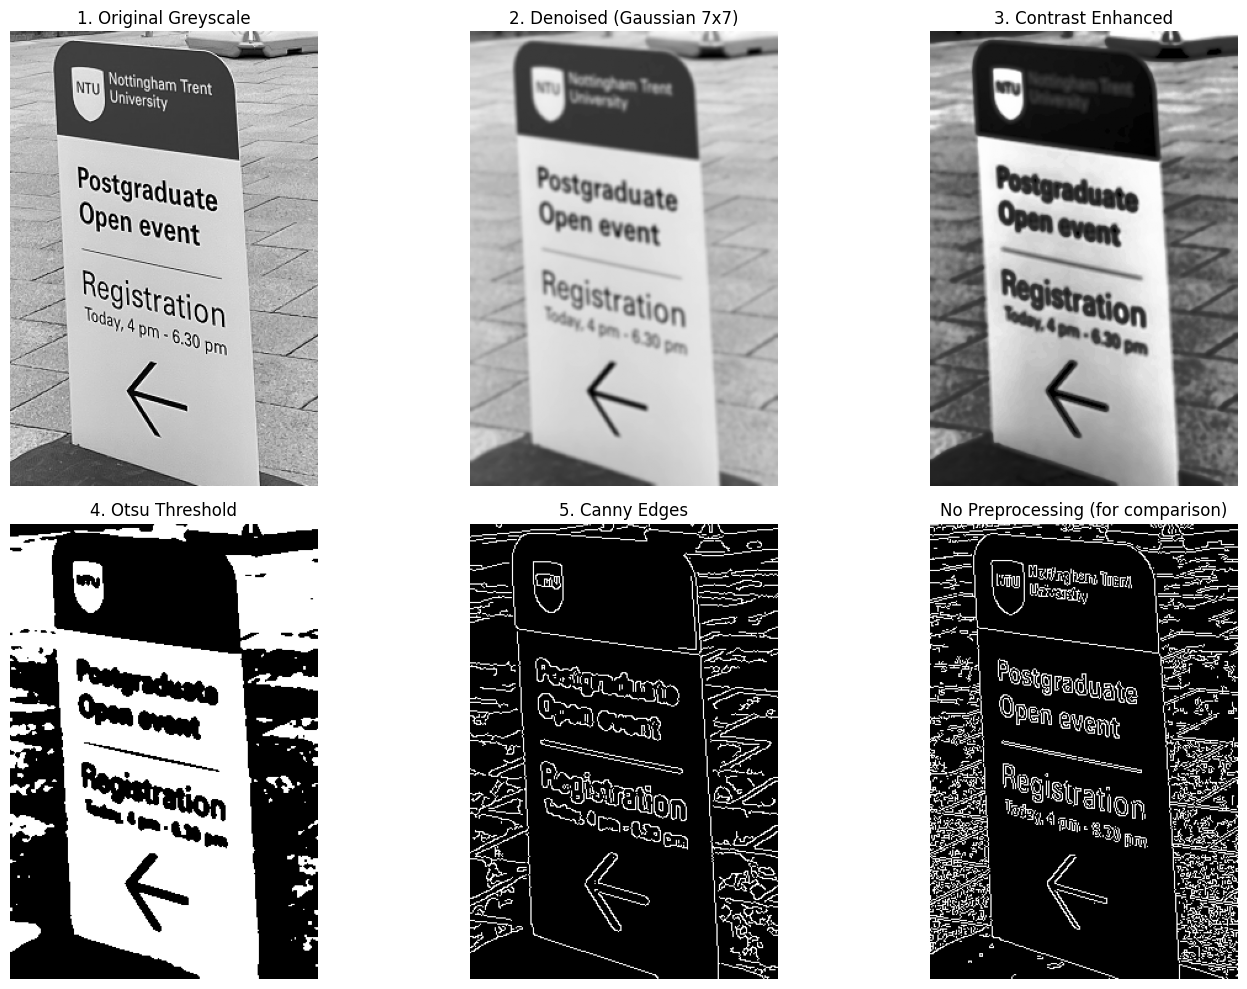

Pipeline Complete!
Notice how each step improves the text visibility


In [80]:
# 6. Stretch task - try to apply preprocessing steps before thresholding and edge detection, can you create your own pipeline that performs well?

# Task 6: Complete preprocessing pipeline

# Step 1: Convert to greyscale (already done)
grey_sign = cv2.cvtColor(postgraduate_sign, cv2.COLOR_RGB2GRAY)

# Step 2: Apply stronger Gaussian blur to remove noise
denoised = cv2.GaussianBlur(grey_sign, (7, 7), 0)

# Step 3: Enhance contrast using histogram equalization
# This makes dark text darker and bright background brighter
enhanced = cv2.equalizeHist(denoised)

# Step 4: Apply Otsu's thresholding
_, pipeline_thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Step 5: Apply Canny for edge detection
pipeline_canny = cv2.Canny(enhanced, 50, 150)

# Display the complete pipeline results
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

axs[0, 0].imshow(grey_sign, cmap="gray")
axs[0, 0].set_title("1. Original Greyscale")
axs[0, 0].axis("off")

axs[0, 1].imshow(denoised, cmap="gray")
axs[0, 1].set_title("2. Denoised (Gaussian 7x7)")
axs[0, 1].axis("off")

axs[0, 2].imshow(enhanced, cmap="gray")
axs[0, 2].set_title("3. Contrast Enhanced")
axs[0, 2].axis("off")

axs[1, 0].imshow(pipeline_thresh, cmap="gray")
axs[1, 0].set_title("4. Otsu Threshold")
axs[1, 0].axis("off")

axs[1, 1].imshow(pipeline_canny, cmap="gray")
axs[1, 1].set_title("5. Canny Edges")
axs[1, 1].axis("off")

# Show comparison: no preprocessing vs full pipeline
axs[1, 2].imshow(cv2.Canny(grey_sign, 50, 150), cmap="gray")
axs[1, 2].set_title("No Preprocessing (for comparison)")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

print("Pipeline Complete!")
print("Notice how each step improves the text visibility")
